In [2]:
# in this want ot predict heartdisease (means can cause heartdisease or heartattack a patient or not)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## EDA

In [3]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.shape

(918, 12)

In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.duplicated().sum()   # it will give duplicates

np.int64(0)

In [8]:
df['HeartDisease'].value_counts()  # there are 508 people  with heart  disease and 410 with no heart disease  # this data is good for pediction bcz equal ratio of heart disease and no heart disease patient otherwise if 90% heart disease had model trains for heart disease only


HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: xlabel='HeartDisease'>

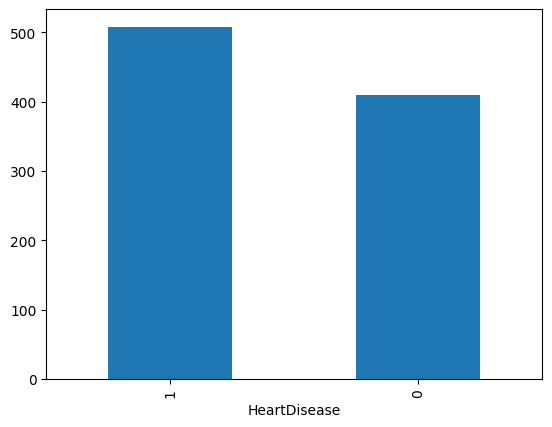

In [9]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [10]:
df.isnull().sum()    # no null values

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

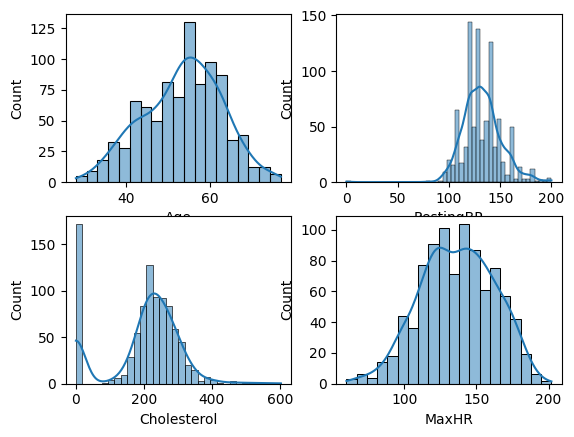

In [11]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)



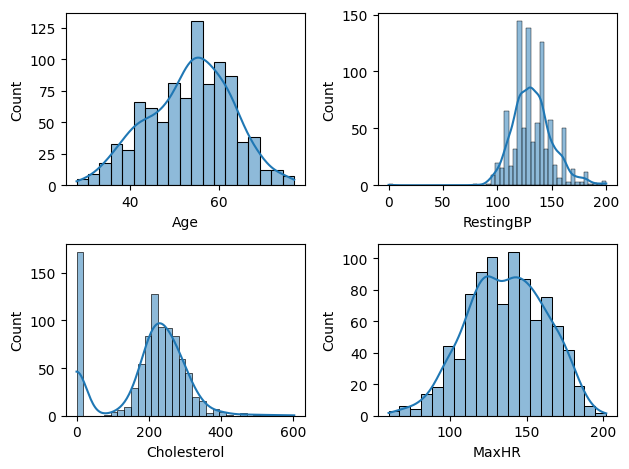

In [12]:
#figures overlap so use tight_layout
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

In [13]:
# if you zoom in at resting bp there is small dot at 0 and a guy cannot have resting bp  0 searched in google,so this can cause prediction so i'll change this value

In [14]:
# also in cholestrol many people have 0  cholestrol,and in google a person can't have 0 cholestrol,so how could out of 918 peeople how 170 people have 0 cholestrol so again need to change this

In [15]:
# this may happen due to sokeone fill all the null values values by 0 ,so due to that this happens

In [16]:
# so to handle  this we clean the data,i'll fill out all these 0's by mean of the data

In [17]:
ch_mean = df.loc[df['Cholesterol'] != 0,'Cholesterol'].mean()   #df.loc[ rows , columns ]  # one for rows that is not 0 and second is only for cholestrol  # if i don't write second cholestrol it will give me whole rows info who not have cholestrol =0

In [18]:
ch_mean

np.float64(244.6353887399464)

In [19]:
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol']=df['Cholesterol'].round(2)

In [20]:
df['Cholesterol']

0      289.0
1      180.0
2      283.0
3      214.0
4      195.0
       ...  
913    264.0
914    193.0
915    131.0
916    236.0
917    175.0
Name: Cholesterol, Length: 918, dtype: float64

In [21]:
# same for resting bp for one 0 dot

In [22]:
rest_mean=df.loc[df['RestingBP']!=0,'RestingBP'].mean()
rest_mean

np.float64(132.54089422028352)

In [23]:
df['RestingBP']=df['RestingBP'].replace(0,rest_mean)
df['RestingBP']=df['RestingBP'].round(2)
df['RestingBP']

0      140.0
1      160.0
2      130.0
3      138.0
4      150.0
       ...  
913    110.0
914    144.0
915    130.0
916    130.0
917    138.0
Name: RestingBP, Length: 918, dtype: float64

In [24]:
# now again see our data after cleaning

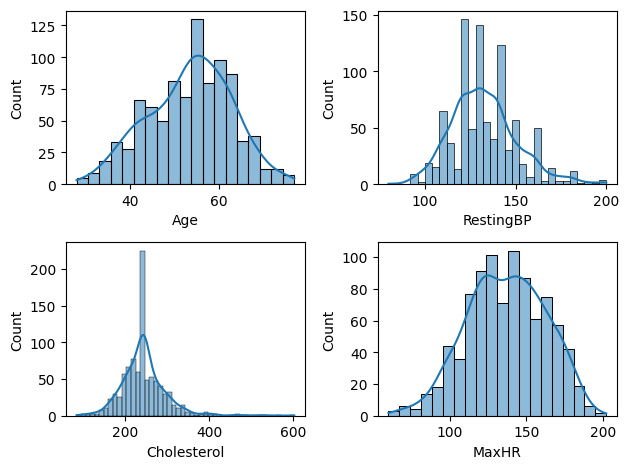

In [25]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()  # now  you cuold see the changes after data cleaning

In [26]:
# now for categorical variable analysis

<Axes: xlabel='Sex', ylabel='count'>

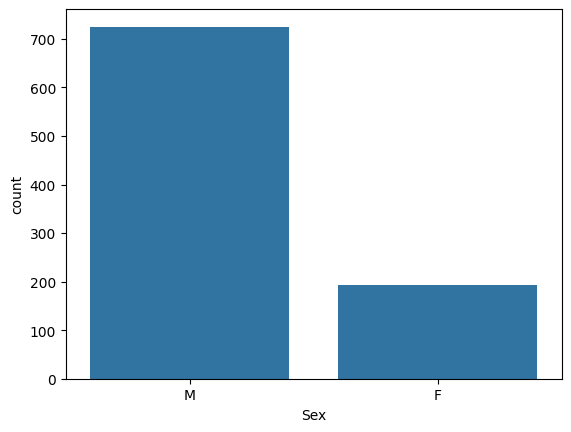

In [27]:
sns.countplot(x=df['Sex'])   # count plot is best for categorical vaiables  # also in this we have seen that male are larger in quantity so our model will train more for males

<Axes: xlabel='ChestPainType', ylabel='count'>

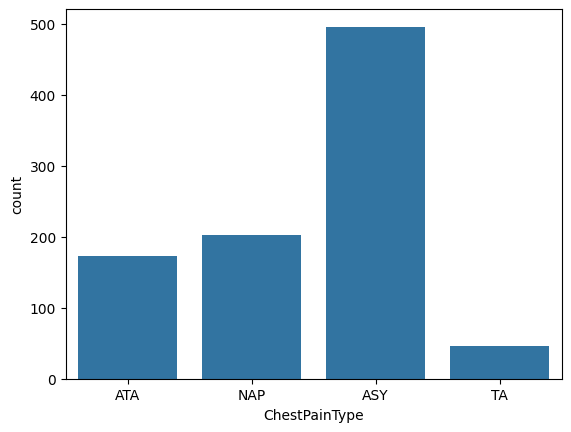

In [28]:
sns.countplot(x=df['ChestPainType'])  # here is four types of pain and we have to predict based on heart disease,and read data you'll understand why we have done 'hue'

<Axes: xlabel='ChestPainType', ylabel='count'>

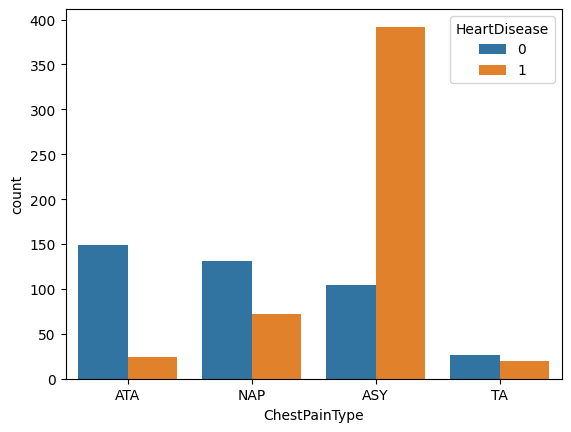

In [29]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])  # here asy chestpain type has more heart disease chance  # 1 yes,0 no

<Axes: xlabel='Sex', ylabel='count'>

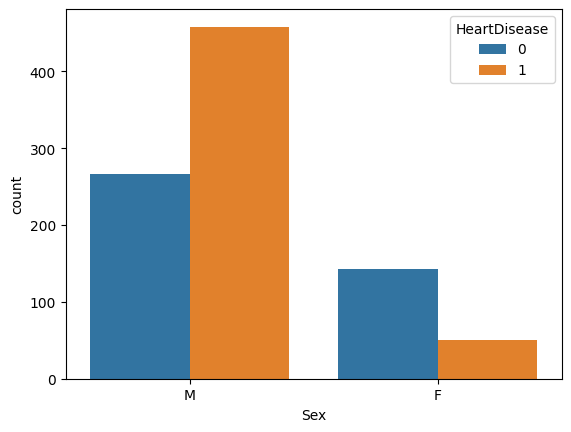

In [30]:
sns.countplot(x=df['Sex'],hue=df['HeartDisease']) # gonna see heartdisease chance in gender
# male having high chance of heartdisease as compare to female

<Axes: xlabel='FastingBS', ylabel='count'>

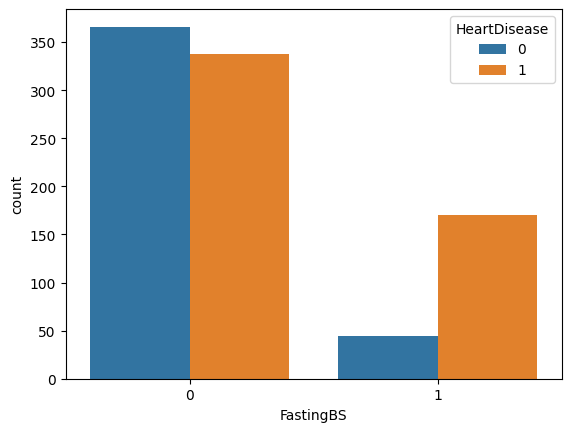

In [31]:
sns.countplot(x=df['FastingBS'],hue=df['HeartDisease'])   # if fasting bs is 1 more chance of heartdisease but if fastingbs is 0 eqaul number of chance

In [32]:
#now box plot will create and box plot can compare one numeric and categorical variable toggether

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

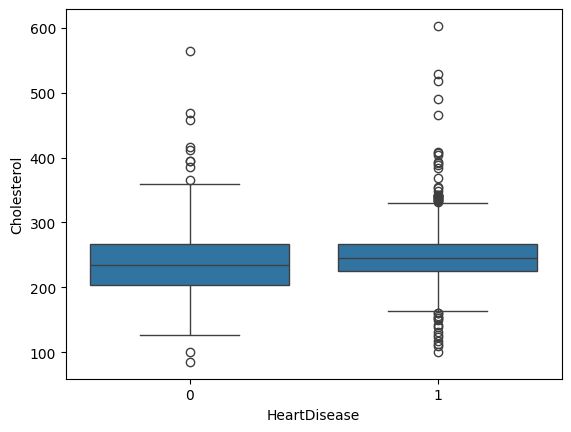

In [33]:
sns.boxplot(y='Cholesterol',x='HeartDisease',data=df)  # here there is a connection btwen heartdisease andd cholestrol here choletsrol having 100 also having heart disease

<Axes: xlabel='HeartDisease', ylabel='Age'>

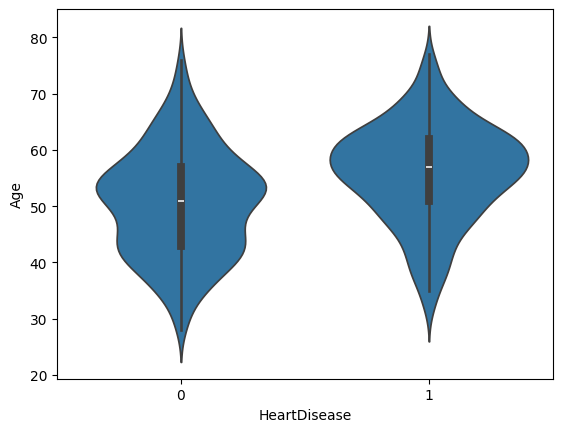

In [34]:
sns.violinplot(data=df,y='Age',x='HeartDisease')    # if age is lies btwn 50-60 chances of heartdisease is common

<Axes: >

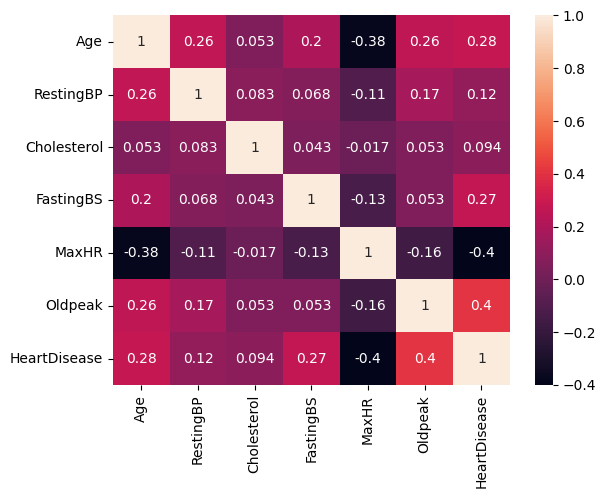

In [35]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [36]:
#heartdisease with age=0.28,restingbp=0.12,cholestrol=0.094,fastingbs=0.27,maxhr=-0.4,oldpeak=0.4

In [37]:
#here cholestrol not work good with heartdisease but maybe it could work good with another variable like  with restingbp so its a hit and trial

## Data Preprocessing and cleaning

In [38]:
# now we could do one hot encode of whole data frame together just by sending whole data frame together, not by individual

In [39]:
df_encode=pd.get_dummies(df,drop_first=True)# drop_first=Ture so that no columns include 

In [40]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [41]:
df_encode=df_encode.astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [42]:
data=df_encode.copy()
data

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [66]:
# for prediction
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [67]:
X=data.drop('HeartDisease',axis=1)
X

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,0,1,0,0,0,0,0,1,0


In [68]:
Y=data['HeartDisease']
Y

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64

In [69]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42) # for those who need non feature scaling

In [70]:
scale=StandardScaler()
X_train_scaled=scale.fit_transform(X_train)
X_test_scaled=scale.fit_transform(X_test)

In [82]:
models={
    'Logistic Regression':LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'SVM':SVC(),
    'Decision Tree':DecisionTreeClassifier(),
    'Naive Bayes':GaussianNB()
}   # create a dictionary  (key:value) then will give name,model where key will replace in place of name and value will replace in place of model when models.item say

In [83]:
result = []

In [84]:
for  name,model in models.items():                     #models.item give(key:value) pair where name =key ,value=pair
    model.fit(X_train_scaled,Y_train)
    y_pred=model.predict(X_test_scaled)
    accuracy=accuracy_score(Y_test,y_pred)
    f1=f1_score(Y_test,y_pred)
    result.append({
        'model':name,
        'accuracy':round(accuracy,4),
        'f1':round(f1,4)
    })
    
    
    

In [85]:
result

[{'model': 'Logistic Regression', 'accuracy': 0.8696, 'f1': 0.8857},
 {'model': 'KNN', 'accuracy': 0.8641, 'f1': 0.8815},
 {'model': 'SVM', 'accuracy': 0.8478, 'f1': 0.8679},
 {'model': 'Decision Tree', 'accuracy': 0.7663, 'f1': 0.7902},
 {'model': 'Naive Bayes', 'accuracy': 0.8533, 'f1': 0.8683}]

In [86]:
# logistic regression coming with best accuracy rate 0.8696 and best f1 score 0.8857

In [87]:
# for frontend

In [92]:
import joblib
joblib.dump(models['Logistic Regression'],'LR.pkl') # LR.pkl for saving as file name # logistic Regression bcz it was the most accurate and f1 model that's why i will save this model in my frontend
joblib.dump(scale,'scaler.pkl')  # saving standard sclaer
joblib.dump(X.columns.tolist(),'columns.pkl') # columns of X will save  in list

['columns.pkl']

In [ ]:
# now we have some new file inside Machine Learning folder  